In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WD = Path(
    "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/"
    "7_HIPHOP_validation/Single-dose_QTL_randomized"
)

INPUT_FILE = WD / "input" / "all_plates_input_long.tsv"
RESULTS_DIR = WD / "blank_corrected_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Use the explicit blank-corrected column.
OD_COLUMN = "OD600_blank_corrected"

CONTROL = "0x"
TREATMENT = "1x"

# Options: "sem" or "ci95"
ERROR_MODE = "sem"

# Add additional plates here when necessary.
PLATE_TO_CONDITION = {
    "CHR13_C_0x": CONTROL,
    "CHR13_T_1x": TREATMENT,
}

In [2]:
# Global plotting style
plt.rcParams.update({
    # General font
    "font.size": 14,
    "font.weight": "bold",

    # Axis titles and labels
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,

    # Figure output
    "figure.titlesize": 18,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("Global plotting style applied.")

Global plotting style applied.


In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep="\t",
    dtype={"sample_id": str},
)

required_columns = {
    "plate",
    "sample_id",
    "gene",
    "replicate",
    "well",
    "OD600_raw",
    "blank_mean",
    "OD600_blank_corrected",
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

df[OD_COLUMN] = pd.to_numeric(
    df[OD_COLUMN],
    errors="coerce",
)

if df[OD_COLUMN].isna().any():
    raise ValueError(
        "Missing or non-numeric blank-corrected OD600 values found."
    )

df["condition"] = df["plate"].map(
    PLATE_TO_CONDITION
)

unmapped = sorted(
    df.loc[df["condition"].isna(), "plate"].unique()
)

if unmapped:
    raise ValueError(
        "Add these plates to PLATE_TO_CONDITION: "
        f"{unmapped}"
    )

df["condition"] = pd.Categorical(
    df["condition"],
    categories=[CONTROL, TREATMENT],
    ordered=True,
)

# Confirm the correction stored in the input file.
recalculated = (
    df["OD600_raw"] - df["blank_mean"]
)

if not np.allclose(
    df["OD600_blank_corrected"],
    recalculated,
    rtol=1e-5,
    atol=1e-5,
    equal_nan=True,
):
    raise ValueError(
        "OD600_blank_corrected does not equal "
        "OD600_raw - blank_mean."
    )

blank_qc = (
    df.groupby("plate", as_index=False)
    .agg(
        blank_mean=("blank_mean", "first"),
        minimum_corrected_OD=(
            OD_COLUMN,
            "min",
        ),
        maximum_corrected_OD=(
            OD_COLUMN,
            "max",
        ),
    )
)

display(blank_qc)

print(f"Measurements: {len(df):,}")
print(f"Strains:      {df['sample_id'].nunique():,}")
print(f"Plates:       {df['plate'].nunique():,}")

,plate,blank_mean,minimum_corrected_OD,maximum_corrected_OD
0,CHR13_C_0x,0.433500,0.273500,0.762500
1,CHR13_T_1x,0.214167,-0.112167,0.733833


Measurements: 180
Strains:      10
Plates:       2


In [4]:
od_summary = (
    df.groupby(
        ["sample_id", "gene", "condition"],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_OD600=(OD_COLUMN, "mean"),
        sd_OD600=(OD_COLUMN, "std"),
        n=(OD_COLUMN, "size"),
    )
)

od_summary["sem_OD600"] = (
    od_summary["sd_OD600"]
    / np.sqrt(od_summary["n"])
)

if ERROR_MODE == "sem":
    od_summary["OD600_error"] = (
        od_summary["sem_OD600"]
    )
    error_label = "SEM"

elif ERROR_MODE == "ci95":
    od_summary["OD600_error"] = (
        1.96 * od_summary["sem_OD600"]
    )
    error_label = "95% CI"

else:
    raise ValueError(
        "ERROR_MODE must be 'sem' or 'ci95'."
    )

display(od_summary)

,sample_id,gene,condition,mean_OD600,sd_OD600,n,sem_OD600,OD600_error
0,1,TIF11,0x,0.591500,0.089655,9,0.029885,0.029885
1,1,TIF11,1x,0.662611,0.038925,9,0.012975,0.012975
2,10,RSN1,0x,0.574056,0.059437,9,0.019812,0.019812
3,10,RSN1,1x,0.683389,0.033560,9,0.011187,0.011187
4,2,TRM732,0x,0.564056,0.032304,9,0.010768,0.010768
5,2,TRM732,1x,0.464944,0.221133,9,0.073711,0.073711
6,3,YMR262W,0x,0.597833,0.079019,9,0.026340,0.026340
7,3,YMR262W,1x,0.624055,0.041928,9,0.013976,0.013976
8,4,BUL1,0x,0.610833,0.036069,9,0.012023,0.012023
9,4,BUL1,1x,0.659389,0.036476,9,0.012159,0.012159


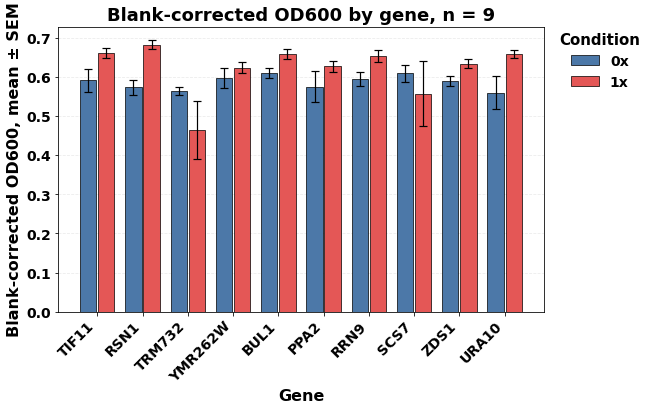

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/blank_corrected_OD600_barplot.png


In [5]:
strain_order = (
    df[["sample_id", "gene"]]
    .drop_duplicates()
    .sort_values("sample_id", kind="stable")
    .reset_index(drop=True)
)

conditions = [CONTROL, TREATMENT]

colors = {
    CONTROL: "#4C78A8",
    TREATMENT: "#E45756",
}

x = np.arange(len(strain_order))

number_of_conditions = len(conditions)
bar_width = 0.8 / number_of_conditions

offsets = (
    np.arange(number_of_conditions)
    - (number_of_conditions - 1) / 2
) * bar_width

fig, ax = plt.subplots(
    figsize=(
        max(10, 0.75 * len(strain_order) + 2),
        6,
    )
)

for offset, condition in zip(
    offsets,
    conditions,
):
    plot_data = (
        od_summary.loc[
            od_summary["condition"] == condition
        ]
        .set_index("sample_id")
        .reindex(strain_order["sample_id"])
    )

    ax.bar(
        x + offset,
        plot_data["mean_OD600"],
        width=bar_width * 0.9,
        yerr=plot_data["OD600_error"],
        capsize=4,
        color=colors[condition],
        edgecolor="black",
        linewidth=0.7,
        label=condition,
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        },
    )

ax.set_xticks(x)

ax.set_xticklabels(
    strain_order["gene"],
    rotation=45,
    ha="right",
)

plt.setp(
    ax.get_xticklabels(),
    fontweight="bold",
)

plt.setp(
    ax.get_yticklabels(),
    fontweight="bold",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    f"Blank-corrected OD600, mean ± {error_label}"
)

replicate_numbers = (
    od_summary["n"]
    .dropna()
    .astype(int)
    .unique()
)

if len(replicate_numbers) == 1:
    n_title = str(replicate_numbers[0])
else:
    n_title = (
        f"{replicate_numbers.min()}–"
        f"{replicate_numbers.max()}"
    )

ax.set_title(
    f"Blank-corrected OD600 by gene, n = {n_title}"
)

# Place legend completely outside the plotting area.
legend = ax.legend(
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
)

legend.get_title().set_fontweight("bold")

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

# Reserve space on the right for the outside legend.
fig.subplots_adjust(
    right=0.80,
    bottom=0.22,
    top=0.88,
)

od_plot_path = (
    RESULTS_DIR / "blank_corrected_OD600_barplot.png"
)

fig.savefig(
    od_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {od_plot_path}")

In [6]:
od_wide = od_summary.pivot(
    index=["sample_id", "gene"],
    columns="condition",
    values=["mean_OD600", "sem_OD600"],
)

fd_summary = od_wide.index.to_frame(
    index=False
)

fd_summary["OD600_0x"] = (
    od_wide[("mean_OD600", CONTROL)]
    .to_numpy()
)

fd_summary["OD600_1x"] = (
    od_wide[("mean_OD600", TREATMENT)]
    .to_numpy()
)

fd_summary["SEM_0x"] = (
    od_wide[("sem_OD600", CONTROL)]
    .to_numpy()
)

fd_summary["SEM_1x"] = (
    od_wide[("sem_OD600", TREATMENT)]
    .to_numpy()
)

nonpositive = (
    (fd_summary["OD600_0x"] <= 0)
    | (fd_summary["OD600_1x"] <= 0)
)

if nonpositive.any():
    display(fd_summary.loc[nonpositive])

    raise ValueError(
        "FD cannot be calculated when a strain-level "
        "mean OD600 is zero or negative. Do not add a "
        "pseudocount without documenting and justifying it."
    )

fd_summary["FD"] = np.log2(
    fd_summary["OD600_1x"]
    / fd_summary["OD600_0x"]
)

# Propagated SEM for log2(T/C), assuming independent
# control and treatment measurements.
fd_summary["FD_SEM"] = (
    np.sqrt(
        (
            fd_summary["SEM_1x"]
            / fd_summary["OD600_1x"]
        ) ** 2
        +
        (
            fd_summary["SEM_0x"]
            / fd_summary["OD600_0x"]
        ) ** 2
    )
    / np.log(2)
)

if ERROR_MODE == "sem":
    fd_summary["FD_error"] = (
        fd_summary["FD_SEM"]
    )

elif ERROR_MODE == "ci95":
    fd_summary["FD_error"] = (
        1.96 * fd_summary["FD_SEM"]
    )

display(fd_summary)

,sample_id,gene,OD600_0x,OD600_1x,SEM_0x,SEM_1x,FD,FD_SEM,FD_error
0,1,TIF11,0.591500,0.662611,0.029885,0.012975,0.163784,0.078174,0.078174
1,10,RSN1,0.574056,0.683389,0.019812,0.011187,0.251516,0.055108,0.055108
2,2,TRM732,0.564056,0.464944,0.010768,0.073711,-0.278780,0.230373,0.230373
3,3,YMR262W,0.597833,0.624055,0.026340,0.013976,0.061930,0.071303,0.071303
4,4,BUL1,0.610833,0.659389,0.012023,0.012159,0.110350,0.038911,0.038911
5,5,PPA2,0.575500,0.627166,0.039191,0.015275,0.124032,0.104341,0.104341
6,6,RRN9,0.595833,0.654055,0.017865,0.015647,0.134504,0.055339,0.055339
7,7,SCS7,0.609278,0.557277,0.022148,0.083117,-0.128704,0.221475,0.221475
8,8,ZDS1,0.590611,0.634500,0.013050,0.010757,0.103411,0.040179,0.040179
9,9,URA10,0.559833,0.658500,0.042213,0.010710,0.234185,0.111284,0.111284


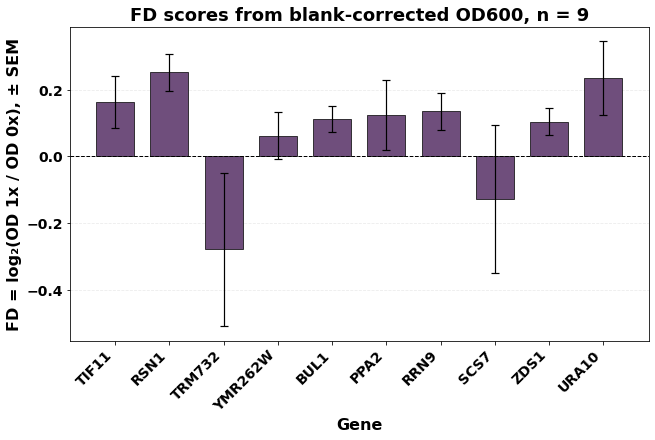

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/blank_corrected_FD_barplot.png


In [7]:
fd_summary = (
    strain_order
    .merge(
        fd_summary,
        on=["sample_id", "gene"],
        how="left",
        validate="one_to_one",
    )
)

x = np.arange(len(fd_summary))

fig, ax = plt.subplots(
    figsize=(
        max(9, 0.75 * len(fd_summary)),
        6,
    ),
    constrained_layout=True,
)

ax.bar(
    x,
    fd_summary["FD"],
    width=0.7,
    yerr=fd_summary["FD_error"],
    capsize=4,
    color="#6F4E7C",
    edgecolor="black",
    linewidth=0.7,
    error_kw={
        "elinewidth": 1.2,
        "capthick": 1.2,
    },
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xticks(x)

ax.set_xticklabels(
    fd_summary["gene"],
    rotation=45,
    ha="right",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    f"FD = log₂(OD 1x / OD 0x), ± {error_label}"
)

ax.set_title(
    f"FD scores from blank-corrected OD600, n = {n_title}"
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

fd_plot_path = (
    RESULTS_DIR / "blank_corrected_FD_barplot.png"
)

fig.savefig(
    fd_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {fd_plot_path}")

In [8]:
od_summary.to_csv(
    RESULTS_DIR / "blank_corrected_OD600_summary.tsv",
    sep="\t",
    index=False,
    float_format="%.6g",
)

fd_summary.to_csv(
    RESULTS_DIR / "blank_corrected_FD_summary.tsv",
    sep="\t",
    index=False,
    float_format="%.6g",
)

print(f"Results saved under: {RESULTS_DIR}")

Results saved under: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results
